# Estratégia de Trading Baseada em Correlação de Padrões de Retornos

Este código implementa uma estratégia quantitativa que identifica **padrões históricos** no comportamento dos retornos de um ativo para prever movimentos futuros.

## 🔹 Como funciona
1. Seleciona-se uma janela recente de retornos (**X dias**).  
2. Busca-se no histórico subsequências de mesmo tamanho.  
3. Calcula-se a **correlação** entre a janela atual e cada subsequência.  
4. Identifica-se a subsequência mais semelhante.  
5. O retorno imediatamente posterior a essa subsequência é usado como **sinal de trade**:
   - Retorno positivo → **compra**  
   - Retorno negativo → **venda**



In [1]:
# bibliotecas 
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt 
from matplotlib.dates import DateFormatter # formatar a data no eixo x 
import matplotlib.gridspec as gridspec # subplots com tamanhos diferentes
plt.style.use('seaborn-v0_8-darkgrid') # mudar o estilo do matplotlib

from yahooquery import Ticker


import warnings
warnings.filterwarnings('ignore')

In [2]:
# Variáveis 
 
# ticker
TICKER =  '^GSPC'

# Janela de comparação 
X_look_back = 90

# número de subsequências históricas para comparar
Y_comp = 10

## Baixando os dados 

In [3]:
# data 
start_date = '2023-01-01'
end_date = '2026-01-01'

ticker_obj = Ticker(TICKER)
df = ticker_obj.history(start = start_date, end = end_date, interval='1d')['close']

df.tail()

symbol  date      
^GSPC   2025-10-13    6654.720215
        2025-10-14    6644.310059
        2025-10-15    6671.060059
        2025-10-16    6629.069824
        2025-10-17    6664.009766
Name: close, dtype: float64

In [4]:
# Arrumando o DataFrame

# resetando o index 
df = df.reset_index()

# pivotando o df para que as colunas virem tickers
df = df.pivot(index = 'date', columns = 'symbol', values= 'close')

# renomeando a coluna com os preços 
df.rename(columns ={TICKER: 'Close'}, inplace=True)

# renomeando o indice 
df.rename_axis('Data', inplace=True)

df.tail()

symbol,Close
Data,
2025-10-13,6654.720215
2025-10-14,6644.310059
2025-10-15,6671.060059
2025-10-16,6629.069824
2025-10-17,6664.009766


In [5]:
# Calculando os retornos diários 
df['Returns'] = df['Close'].pct_change(1)*100

# Alvo 
df['Target'] = df['Returns'].shift(-1)

# Alvo Binário 
df['Target_Bin'] = np.where(df['Target'] >= 0, 1, -1)

# Z-Score
df['z_score'] = (df['Returns'] - df['Returns'].mean())/df['Returns'].std() 
df['z_score'] = df['z_score'].round(2)  # arredondado

In [6]:
df.tail()

symbol,Close,Returns,Target,Target_Bin,z_score
Data,,,,,
2025-10-13,6654.720215,1.559867,-0.156433,-1,1.53
2025-10-14,6644.310059,-0.156433,0.402600,1,-0.25
2025-10-15,6671.060059,0.402600,-0.629439,-1,0.33
2025-10-16,6629.069824,-0.629439,0.527072,1,-0.74
2025-10-17,6664.009766,0.527072,NaN,-1,0.46


## Criação das variáveis 

In [7]:
# criando uma cópia do df para a realização do código 
df1 = df.copy()

In [8]:
# criando o vetor contendo os últimos y retornos 

def get_last_returns( row, window, data):
    row_position = data.index.get_loc(row.name) # posição da linha do DataFrame
    if row_position < window: # se não há retornos suficientes
        return list(data['z_score'].iloc[:row_position +1].dropna()) # +1 para pegar os valores da linha atual 
    else:
        return list(data['z_score'].iloc[row_position-window +1 : row_position +1].dropna())
    

# aplicando a função para criar a coluna 
df1['Last_Values'] = df1.apply(lambda row: get_last_returns(row, Y_comp, df1), axis=1)


df1.tail()

symbol,Close,Returns,Target,Target_Bin,z_score,Last_Values
Data,,,,,,
2025-10-13,6654.720215,1.559867,-0.156433,-1,1.53,"[0.34, 0.27, -0.02, -0.08, 0.29, -0.48, 0.52, ..."
2025-10-14,6644.310059,-0.156433,0.402600,1,-0.25,"[0.27, -0.02, -0.08, 0.29, -0.48, 0.52, -0.37,..."
2025-10-15,6671.060059,0.402600,-0.629439,-1,0.33,"[-0.02, -0.08, 0.29, -0.48, 0.52, -0.37, -2.9,..."
2025-10-16,6629.069824,-0.629439,0.527072,1,-0.74,"[-0.08, 0.29, -0.48, 0.52, -0.37, -2.9, 1.53, ..."
2025-10-17,6664.009766,0.527072,NaN,-1,0.46,"[0.29, -0.48, 0.52, -0.37, -2.9, 1.53, -0.25, ..."


In [9]:
def calculate_correlation_and_index(row, window, data, x_lines):
    """
    Calcula a correlação entre o vetor de retornos da linha atual e
    os vetores das últimas 'x_lines' linhas anteriores.

    Parâmetros:
        row (pd.Series): linha atual do DataFrame
        window (int): não está sendo usado aqui (mas pode ser útil em ajustes futuros)
        data (pd.DataFrame): DataFrame contendo a coluna 'Last_Returns'
        x_lines (int): número de linhas anteriores para comparar

    Retorna:
        pd.Series: {'Correlation': maior correlação encontrada,
                    'Max_Corr_Index': quantos dias atrás ocorreu essa correlação}
    """
    
    row_position = data.index.get_loc(row.name)
    current_vector = row['Last_Values']

    # se vetor atual for muito curto, não faz sentido calcular correlação
    if len(current_vector) < 2:
        return pd.Series({
            'Max_Correlation': np.nan, 'Max_Corr_Index': np.nan,
            'Min_Correlation': np.nan, 'Min_Corr_Index': np.nan
            })

    best_corr = -np.inf
    best_idx = np.nan
    worst_corr = np.inf
    worst_idx = np.nan

    # percorre as últimas x_lines linhas
    for i in range(1, x_lines + 1):
        if row_position - i < 0:
            continue  # saiu dos limites do DataFrame

        previous_vector = data['Last_Values'].iloc[row_position - i]

        # garante que os vetores tenham mesmo tamanho
        if len(previous_vector) == len(current_vector) and len(previous_vector) >= 2:
            try:
                corr, _ = pearsonr(current_vector, previous_vector)

                # maior correlação 
                if not np.isnan(corr) and corr > best_corr:
                    best_corr = corr
                    best_idx = i
                if not np.isnan(corr) and corr < worst_corr:
                    worst_corr = corr
                    worst_idx = i
            except Exception:
                continue

    # se não encontrou correlação válida, retorna NaN
    if best_corr == -np.inf:
        best_corr, best_idx = np.nan, np.nan
    if worst_corr == np.inf:
        worst_corr, worst_idx = np.nan, np.nan

    return pd.Series({
        'Max_Correlation': best_corr, 'Max_Corr_Index': best_idx,
        'Min_Correlation': worst_corr, 'Min_Corr_Index': worst_idx
    })

In [10]:
# Adicionado ao df

df1[['Max_Correlation', 'Max_Corr_Index','Min_Correlation', 'Min_Corr_Index']] = df1.apply(lambda row: calculate_correlation_and_index(row, Y_comp, df1, X_look_back), axis=1)

In [11]:
df1.tail()

symbol,Close,Returns,Target,Target_Bin,z_score,Last_Values,Max_Correlation,Max_Corr_Index,Min_Correlation,Min_Corr_Index
Data,,,,,,,,,,
2025-10-13,6654.720215,1.559867,-0.156433,-1,1.53,"[0.34, 0.27, -0.02, -0.08, 0.29, -0.48, 0.52, ...",0.901907,49.0,-0.582158,34.0
2025-10-14,6644.310059,-0.156433,0.402600,1,-0.25,"[0.27, -0.02, -0.08, 0.29, -0.48, 0.52, -0.37,...",0.895702,49.0,-0.754914,34.0
2025-10-15,6671.060059,0.402600,-0.629439,-1,0.33,"[-0.02, -0.08, 0.29, -0.48, 0.52, -0.37, -2.9,...",0.902203,49.0,-0.761838,34.0
2025-10-16,6629.069824,-0.629439,0.527072,1,-0.74,"[-0.08, 0.29, -0.48, 0.52, -0.37, -2.9, 1.53, ...",0.893271,49.0,-0.768141,34.0
2025-10-17,6664.009766,0.527072,NaN,-1,0.46,"[0.29, -0.48, 0.52, -0.37, -2.9, 1.53, -0.25, ...",0.899479,49.0,-0.778857,34.0


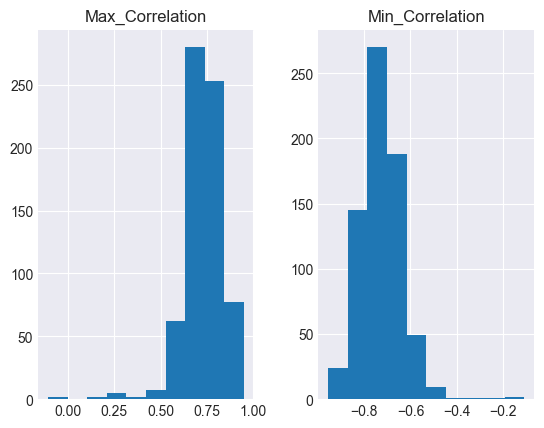

In [12]:
# Histograma da correlação 
df1[['Max_Correlation', 'Min_Correlation']].hist();

## Pegando o sinal de trade 

In [13]:
# Pegando o sinal do dia seguinte ao vetor com maior correlação 

def take_signal(row, name_col, data):
    '''
    Pega o Target binário do dia seguinte ao vetor com maior/menor correlação.

    row: linha atual do DataFrame (já contendo 'Max_Corr_Index')
    data: DataFrame completo com colunas ['Target', 'Last_Returns', 'Max_Corr_Index']
    '''
    row_position = data.index.get_loc(row.name)
    
    max_corr_index = row[name_col]

    # se não existir correlação válida 
    if pd.isna(max_corr_index):
        return np.nan

    # posição do vetor com maior correlação 
    pos_corr = row_position - int(max_corr_index)
    
    # garantir que existe 'dia seguinte'
    if pos_corr + 1 < len(data):
        return data['Target_Bin'].iloc[pos_corr]
    else:
        return np.nan

In [14]:
# Aplicando a função para a 'Max_Corr_Index'
df1['signal_target_long'] = df1.apply(lambda row: take_signal(row, 'Max_Corr_Index' ,df1), axis = 1)

# Aplicando a função para a 'Min_Corr_Index'
df1['signal_target_short'] = df1.apply(lambda row: take_signal(row, 'Min_Corr_Index' ,df1), axis = 1)

# Como o sinal de short temos uma correlção negativa queremos o sinal investo 
df1['signal_target_short'] = df1['signal_target_short']*(-1)

In [15]:
df1.tail()

symbol,Close,Returns,Target,Target_Bin,z_score,Last_Values,Max_Correlation,Max_Corr_Index,Min_Correlation,Min_Corr_Index,signal_target_long,signal_target_short
Data,,,,,,,,,,,,
2025-10-13,6654.720215,1.559867,-0.156433,-1,1.53,"[0.34, 0.27, -0.02, -0.08, 0.29, -0.48, 0.52, ...",0.901907,49.0,-0.582158,34.0,-1.0,-1.0
2025-10-14,6644.310059,-0.156433,0.402600,1,-0.25,"[0.27, -0.02, -0.08, 0.29, -0.48, 0.52, -0.37,...",0.895702,49.0,-0.754914,34.0,1.0,-1.0
2025-10-15,6671.060059,0.402600,-0.629439,-1,0.33,"[-0.02, -0.08, 0.29, -0.48, 0.52, -0.37, -2.9,...",0.902203,49.0,-0.761838,34.0,-1.0,-1.0
2025-10-16,6629.069824,-0.629439,0.527072,1,-0.74,"[-0.08, 0.29, -0.48, 0.52, -0.37, -2.9, 1.53, ...",0.893271,49.0,-0.768141,34.0,1.0,1.0
2025-10-17,6664.009766,0.527072,NaN,-1,0.46,"[0.29, -0.48, 0.52, -0.37, -2.9, 1.53, -0.25, ...",0.899479,49.0,-0.778857,34.0,-1.0,1.0


## Backtest da estratégia 

In [16]:
# Correlação mínima aceitável 
min_corr = 0.7

# regras de trade 
rule_positive_corr = (df1['Max_Correlation'].abs() >= df1['Min_Correlation'].abs()) & (df1['Max_Correlation'] >= min_corr)
rule_negative_corr = (df1['Max_Correlation'].abs() < df1['Min_Correlation'].abs()) & (df1['Min_Correlation'] <= min_corr*(-1))

# Trade 
df1['signal'] = np.where(rule_positive_corr, df1['signal_target_long'],
                         np.where(rule_negative_corr, df1['signal_target_short'], 0))

In [17]:
# Números de trade 
df1['signal'].value_counts()

signal
-1.0    306
 1.0    290
 0.0    105
Name: count, dtype: int64

In [18]:
# Calculo dos retornos 

# taxa de trade 
fee = 0.005

# retorno da estratégia 
df1['ret'] = df1['signal']*df1['Target']-fee

# retorno acumulado 
df1['ret_acc'] = df1['ret'].cumsum()

In [19]:
# retorno do ativo acumulado 
df1[f'{TICKER}_acc'] = df1['Returns'].cumsum()

## Gráfico dos Retornos 

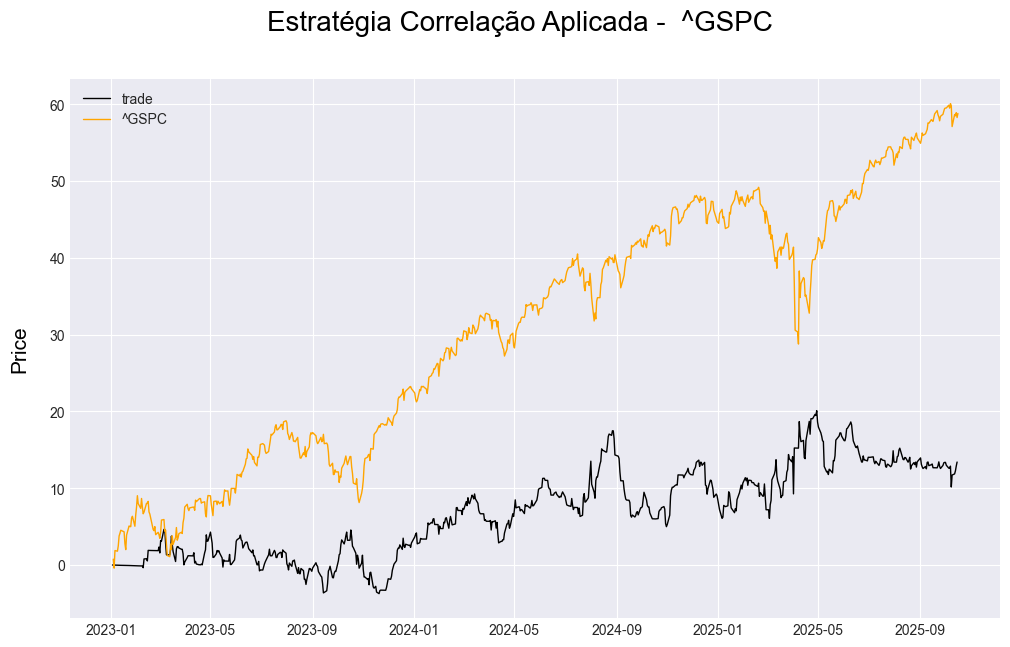

In [20]:
fig =  plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(1, 1, height_ratios=[1],  hspace=0.2) # define a proporção de altura dos subplots

ax0 = fig.add_subplot(gs[0]) # primeiro subplot
axs = [ax0] # lista de eixos para facilitar o acesso

# Plotando o gráfico de preços e o valor z
axs[0].plot(df1.index, df1['ret_acc'], color='black', label= 'trade', linewidth=1)
axs[0].plot(df1.index, df1[f'{TICKER}_acc'], color='orange', label= TICKER, linewidth=1)




axs[0].set_ylabel('Price', fontsize=15, color='black', labelpad=15)
axs[0].legend()
axs[0].grid(True)  


# Fixando as legendas no canto superior esquerdo
axs[0].legend(loc='upper left')



# Layout 
fig.tight_layout()
fig.suptitle(f'Estratégia Correlação Aplicada -  {TICKER}', fontsize=20, color='black')
fig.show()

# **Conclusão**

Apesar de a ideia inicial sugerir a possibilidade de bons resultados — já que utiliza a análise da correlação entre os retornos recentes e janelas móveis de retornos passados, o backtest realizado mostrou que essa abordagem se revelou **ineficaz** na prática.